In [1]:
import os
import pickle
import random
import numpy as np
from collections import Counter
from PIL import Image
from tqdm.notebook import tqdm  # 주피터용 tqdm으로 변경

from kiwipiepy import Kiwi
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 시각화 설정
%matplotlib inline

In [16]:
def extract_keywords_from_data(text_list, kiwi):
    words = []
    print(f"📊 총 {len(text_list)}개의 제품군 데이터를 분석합니다.")

    for text in tqdm(text_list, desc="토크나이징 중"):
        if not text or len(text.strip()) == 0:
            continue
            
        result = kiwi.analyze(text)
        if not result: continue
        tokens = result[0][0]
        
        for t in tokens:
            # 명사뿐만 아니라 형용사, 동사, 어근, 부사까지 모두 수집하여 필터링 후보로 보냄
            if t.tag in ['NNG', 'NNP', 'XR', 'VA', 'VV', 'MAG']:
                words.append(t.form)
                    
    return words

In [17]:
import os
import pickle
from collections import Counter
from tqdm.notebook import tqdm

# 파일 경로 설정
pickle_file = "class_type_product_data_whole.pkl" 
kiwi = Kiwi()

# 1. 제외할 단어 (불용어)
exclude_words = ['하다', '있다', '되다', '보기', '사용', 'LG', '제품', '확인', '문의', '드립니다', '알려', '주세요', '가능', '어떻게']

# 2. 통합 감정 키워드 (긍정 + 부정 대폭 확장)
sentiment_keywords = [
    # 부정 (더 짧은 어근 위주로 수정하여 매칭 확률 업)
    '불편', '어렵', '복잡', '귀찮', '번거롭', '모르', '힘듦', '나쁨', '헷갈', '안됨', '오류', 
    '버벅', '끊김', '느림', '실패', '불가', '소음', '진동', '냄새', '고장', '이상함', '불량', 
    '문제', '누수', '과열', '비싸', '실망', '아쉽', '부족', '엉망', '답답', '짜증', '불만', 
    '안돼', '안나', '안켜', '무거', '힘들', '피곤', '스트레스',
    # 긍정
    '좋', '편함', '편리', '쉬움', '쉬워', '빠름', '빨라', '만족', '추천', '최고', '감동', 
    '깔끔', '예쁨', '조용', '간편', '유용', '훌륭', '가볍', '든든', '신기', '재밌', '즐거', 
    '부드럽', '선명', '깨끗', '강추', '득템', '성공', '해결', '신세계', '대만족', '이쁨', 
    '고급', '튼튼', '안심', '행복', '감사', '덕분'
]

if not os.path.exists(pickle_file):
    print(f"❌ 에러: '{pickle_file}' 파일이 없습니다.")
else:
    with open(pickle_file, "rb") as f:
        raw_data = pickle.load(f)
    
    all_texts = []
    for class_name in raw_data:
        for type_name in raw_data[class_name]:
            all_texts.append(raw_data[class_name][type_name][1])

    # 키워드 추출
    all_tokens = extract_keywords_from_data(all_texts, kiwi)
    word_counts = Counter(all_tokens)
    
    final_counts = {}

    # 필터링 로직 (정밀 매칭)
    for word, count in tqdm(word_counts.items(), desc="감정 키워드 정제 중"):
        if word in exclude_words or len(word) < 2:
            continue
            
        # 단어 자체가 키워드이거나, 단어 내부에 키워드가 포함된 경우
        if any(key in word for key in sentiment_keywords):
            final_counts[word] = final_counts.get(word, 0) + count
            
    print(f"✅ 정제 완료! 추출된 전체 감정 단어 수: {len(final_counts)}개")

📊 총 24개의 제품군 데이터를 분석합니다.


토크나이징 중:   0%|          | 0/24 [00:00<?, ?it/s]

감정 키워드 정제 중:   0%|          | 0/855 [00:00<?, ?it/s]

✅ 정제 완료! 추출된 전체 감정 단어 수: 10개


🎨 배경이 투명한 보노보노 워드클라우드 생성 중...


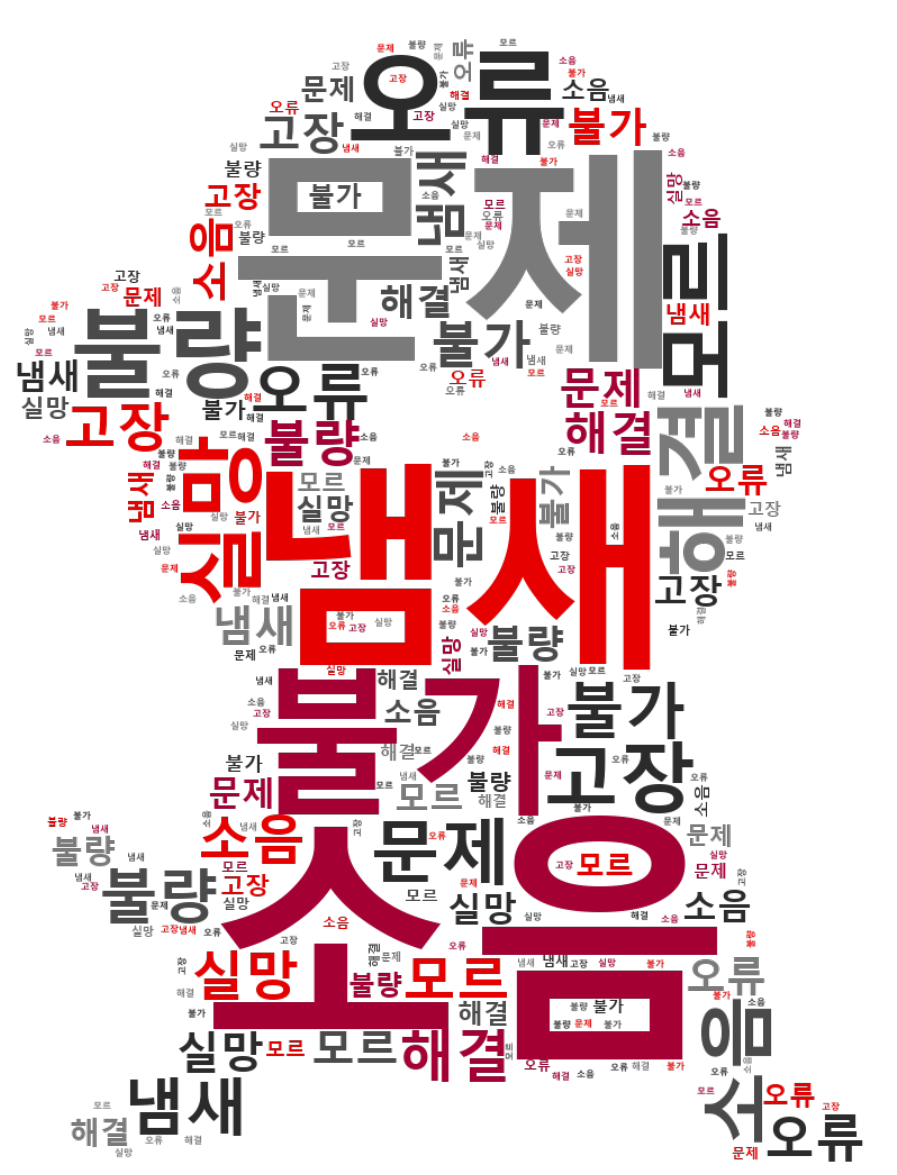

✅ 시각화 완료! 투명 배경 파일 저장됨: lg_qna_whole_wordcloud.png
Object `수정했나요` not found.


In [18]:
# 설정값
font_path = 'C:/Windows/Fonts/malgunbd.ttf' # 윈도우 기준
mask_path = 'bonobono.jpg' 
output_img = 'lg_qna_whole_wordcloud.png'

try:
    mask_img = Image.open(mask_path).convert("L")
    # 배경 이진화 (240보다 밝은 곳은 배경으로 인식)
    mask_img = mask_img.point(lambda x: 255 if x > 240 else 0)
    mask = np.array(mask_img)
except Exception as e:
    print(f"⚠️ 마스크 이미지 처리 오류: {e}")
    mask = None

# 2. 워드클라우드 설정 (오류 수정을 위해 contour 설정 제거)
lg_colors = ["#A50034", "#2B2B2B", "#4A4A4A", "#7A7A7A", "#E60000"]
def lg_color_func(*args, **kwargs):
    return random.choice(lg_colors)

print("🎨 배경이 투명한 보노보노 워드클라우드 생성 중...")

wordcloud = WordCloud(
    font_path=font_path,
    background_color=None,    # 배경 투명
    mode='RGBA',              # 투명 채널 활성화
    mask=mask,
    width=2000, height=2000,
    max_words=300,
    min_font_size=2,
    max_font_size=300,
    relative_scaling=0.1,
    repeat=True,
    color_func=lg_color_func,
    # --- 핵심 수정: 투명 배경일 때 오류를 일으키는 contour 설정을 끕니다 ---
    contour_width=0,          
    contour_color=None        
    # -------------------------------------------------------------
).generate_from_frequencies(final_counts)

# 3. 출력 및 투명 파일 저장
plt.figure(figsize=(15, 15))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

# 파일 저장 시 transparent=True 필수!
plt.savefig(output_img, dpi=300, transparent=True)
plt.show()

print(f"✅ 시각화 완료! 투명 배경 파일 저장됨: {output_img}")
💡 왜 이렇게 수정했나요?